# Develop quick stuff

For temporary/quick stuff to be developed

In [1]:
import os
import sys

base_path = os.path.abspath("./..")
thesis_path = os.path.join(base_path, "thesis")
for p in [base_path, thesis_path]:
  if p not in sys.path:
      sys.path.append(p)

from IPython.display import display, Markdown
import torch


from experiments.acceptance_loop_cv_based_MNAR import THRESHOLD_BASIS, METRIC_CATEGORIES, EXPECTATION_TYPES, REAL_PERFORMANCE_TYPES
from berebasl.simulation.credit_data_simulation import CreditData, CreditDataGenerator, GaussianMixture

torch.set_num_threads(16)

try:
   torch.set_num_interop_threads(32)
except RuntimeError:
   pass

In [2]:
os.chdir(base_path)
%run "thesis/helper_scripts/general.py"

In [3]:
os.chdir(thesis_path)


grid_path = os.path.abspath('../berebasl/data/simulations/mnar_grid_hyp_vec')
grid_biases = extract_biases_from_dirnames(grid_path)

all_sim_objs = extract_all_sim_objs_vec(grid_path, grid_biases)
all_corrs = torch.stack([sim_objs['corr_to_hidden'] for sim_objs in all_sim_objs.values()], dim=0)
assert torch.all(all_corrs[[0]] == all_corrs)

base_sim_bias = '0_0'
base_sim = all_sim_objs[base_sim_bias]
wished_corr = -0.4
base_sim_objs = slice_vec_sim(base_sim, wished_corr)

base_dgp_unsliced = base_sim["data_generator"]
dgp_base = base_sim_objs["data_generator"]

In [14]:
from berebasl.estimation.classifiers import BatchedLogistic
from copy import deepcopy

all_threshold_lbls = [th + '_' + m for th in THRESHOLD_BASIS for m in METRIC_CATEGORIES]

for str_bias, sim_objs in all_sim_objs.items():
    credit_data: CreditData = deepcopy(sim_objs["credit_data"])
    acc_flags_per_th_alternative = {k: v.clone() for k, v in sim_objs["alternative_accepted"].items()}
    lbl_acc_flag_in_data = set(all_threshold_lbls) - set(acc_flags_per_th_alternative.keys())
    assert len(lbl_acc_flag_in_data) == 1
    lbl_acc_flag_in_data = next(lbl_acc_flag_in_data.__iter__())
    acc_flags_per_th_alternative["through_the_door"] = torch.ones_like(
        next(acc_flags_per_th_alternative.values().__iter__())
    )

    betas_per_acc = {}

    for acc_k in [lbl_acc_flag_in_data] + list(acc_flags_per_th_alternative.keys()):
        if acc_k != lbl_acc_flag_in_data:
            credit_data.change_acceptance_flag(acc_flags_per_th_alternative[acc_k])

        feats, lbls, mask_valid, gen_round = credit_data.accepts(include_gen_round=True, include_mask_valid=True)
        G = credit_data.last_gen_round+1
        Co, N, K = feats.shape

        feats = feats.unsqueeze(1).expand(Co, G, N, K)
        lbls = lbls.unsqueeze(1).expand(Co, G, N)

        arange_G = torch.arange(G, device=gen_round.device, dtype=gen_round.dtype)

        mask_gen_round_ok = gen_round.unsqueeze(1) <= arange_G.view(1, G, 1)

        mask_valid_and_gen_round_ok = mask_valid.unsqueeze(1) & mask_gen_round_ok


        batched_lr = BatchedLogistic(n_features=K-1, batch_shape = lbls.shape[:-1], device=feats.device, dtype=feats.dtype)
        model_vars = [f for f in range(K) if f != (sim_objs["var_to_hide"] % K)]
        print("Starting training", str_bias, acc_k)
        batched_lr.fit(feats[..., model_vars].clone(), lbls.clone(), mask_valid_obs=mask_valid_and_gen_round_ok)
        betas_per_acc[acc_k] = batched_lr.beta.squeeze(-1)

    torch.save(betas_per_acc, os.path.join(grid_path, 'bias_' + str_bias, "betas_per_acc_and_gen.pt"))


Starting training 0_0 acc_based_roc
Starting training 0_0 oracle_ks


KeyboardInterrupt: 

In [ ]:
all_betas_per_acc = {
    b : torch.load(
        os.path.join(grid_path, 'bias_' + b, 'betas_per_acc_and_gen.pt'),
        map_location='cpu',
        weights_only=False
    )
    for b in grid_biases.keys()
}

In [ ]:
betas_all = torch.stack([all_betas_per_acc[b]["through_the_door"] for b in grid_biases.keys()], dim=0)

B, Co, G, K = betas_all.shape


torch.Size([5, 7, 301, 3])

In [ ]:
betas_acc = torch.stack([
    all_betas_per_acc[b][acc_k] 
    for b in grid_biases.keys()
    for acc_k in ("acc_based_roc", "oracle_roc")
], dim=0)
betas_acc.reshape(B, -1, Co, G, K).transpose(1,2) .shape

torch.Size([5, 7, 2, 301, 3])

In [ ]:
betas_acc.shape

torch.Size([5, 7, 2, 301, 3])

In [ ]:
alpha = 0.6
y_offset_mul = 0.05
linewidth = 2
corr_to_hidden = base_sim["corr_to_hidden"]
betas_all = torch.stack([all_betas_per_acc[b]["through_the_door"] for b in grid_biases.keys()], dim=0)
B, Co, G, K = betas_all.shape
betas_acc = torch.stack([
    all_betas_per_acc[b][acc_k] 
    for b in grid_biases.keys()
    for acc_k in ("acc_based_roc", "oracle_roc")
], dim=0)

betas_acc = betas_acc.reshape(B, -1, Co, G, K).transpose(1,2) 
A = betas_acc.size(2)

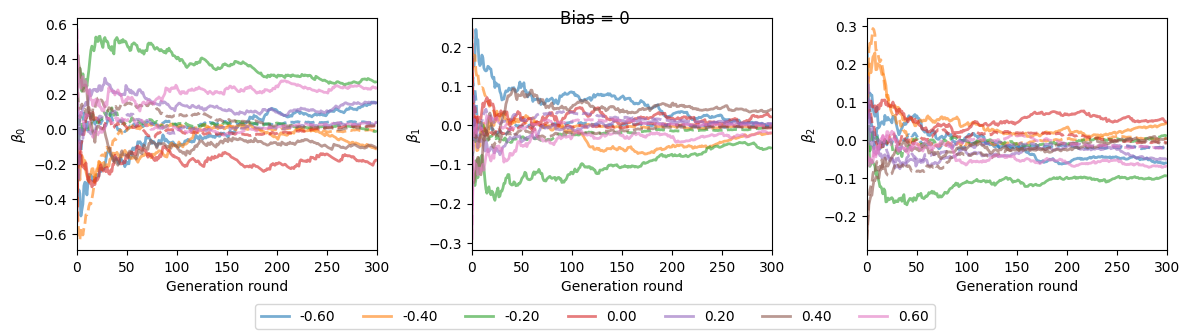

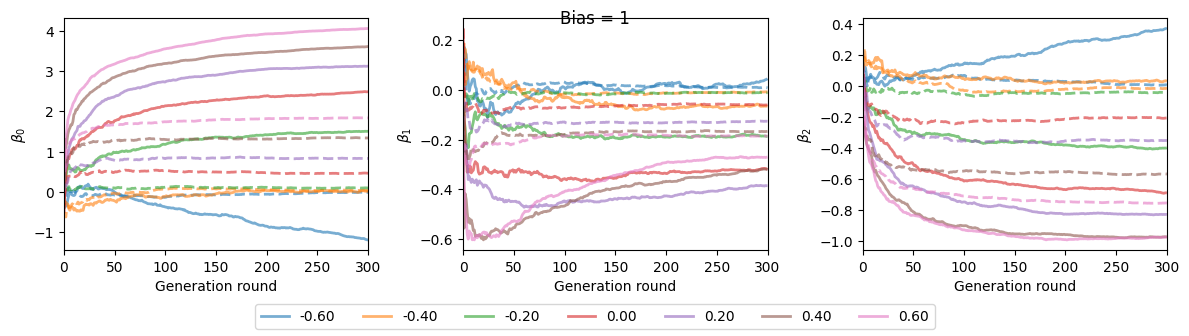

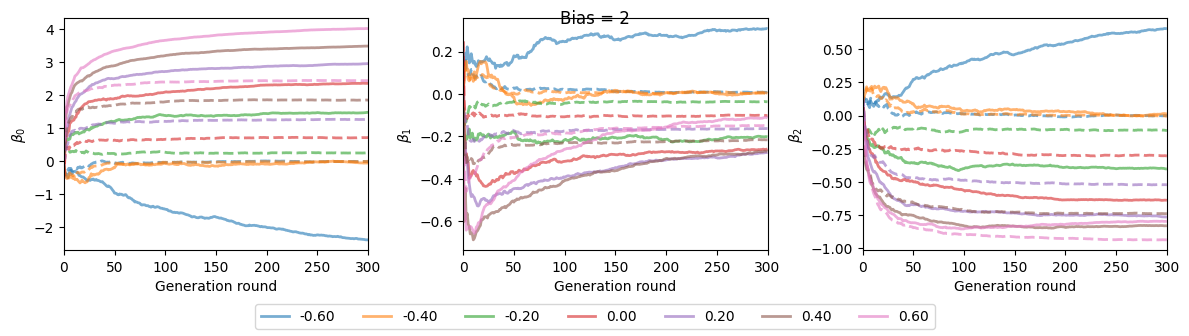

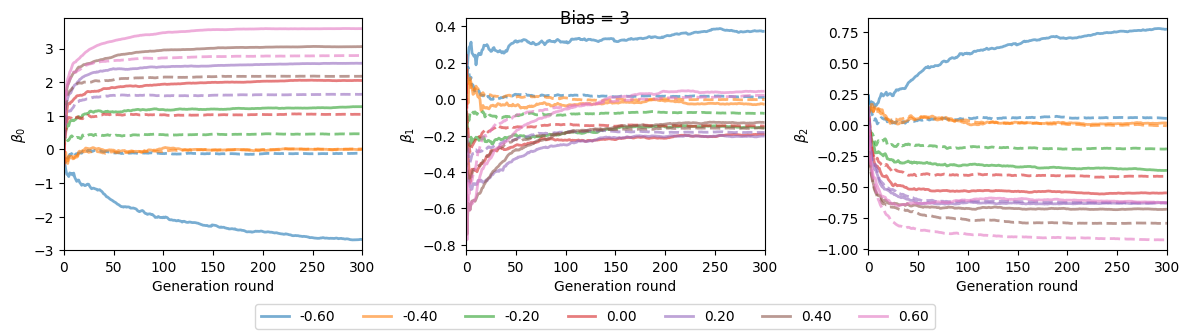

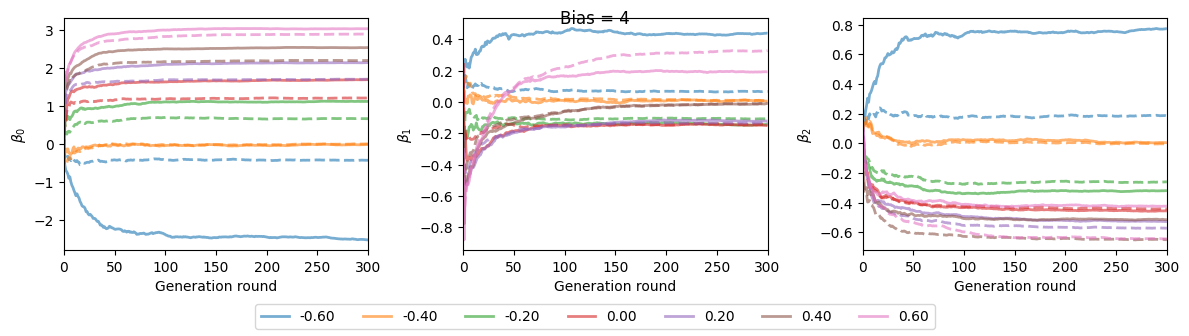

In [ ]:
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

alpha = 0.6
y_offset_mul = 0.05
linewidth = 2
corr_to_hidden = base_sim["corr_to_hidden"]
betas_all = torch.stack([all_betas_per_acc[b]["through_the_door"] for b in grid_biases.keys()], dim=0)
B, Co, G, K = betas_all.shape
betas_acc = torch.stack([
    all_betas_per_acc[b][acc_k] 
    for b in grid_biases.keys()
    for acc_k in ("acc_based_roc", "oracle_roc")
], dim=0)

betas_acc = betas_acc.reshape(B, -1, Co, G, K)
A = betas_acc.size(1)

beta_diffs = betas_all.unsqueeze(1) - betas_acc

for b_idx in range(B):
    betas = beta_diffs[b_idx]

    fig, axes = plt.subplots(1, K, figsize=(4*K, 3 + 0.3))
    #fig.subplots_adjust(bottom=0.2)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i)[:3] + (alpha,) for i in range(Co) for _ in range(A)]
    line_styles_ao = {0 : "solid", 1 : "dashed", 2 : "dotted"} # [accept_based, oracle]
    line_styles = [line_styles_ao[ao] for i in range(Co) for ao in range(A)]

    for k in range(K):
        ax = axes[k]
        betas_k = betas[..., k]          # [AO, Co, G]
        gen_round = torch.arange(G)

        # Build segments for LineCollection
        segments = [torch.stack([gen_round, betas_k[ao, co]], dim=-1) for co in range(Co) for ao in range(A)]
        lc = LineCollection(segments, colors=colors, linewidths=linewidth, linestyles=line_styles)

        ax.add_collection(lc)
        ax.set_xlim(0, G-1)
        min_beta, max_beta = betas_k.min().item(), betas_k.max().item()
        add_rest_beta = y_offset_mul * (max_beta - min_beta)
        ax.set_ylim(min_beta - add_rest_beta, max_beta + add_rest_beta)

        #ax.set_title(f"K = {k}")
        ax.set_ylabel(f"$\\beta_{{{k}}}$")
        ax.set_xlabel("Generation round")
        #ax.grid(True)


    handles_corrs = [Line2D([0], [0], linewidth=linewidth, color=c) for c in colors[::A]]
    labels_corrs = [f"{corr.item():.2f}" for corr in corr_to_hidden]


    plt.tight_layout()
    fig.subplots_adjust(bottom=0.25)
    fig.legend(
        handles_corrs,
        labels_corrs,
        ncol=len(handles_corrs),
        loc="lower center"
    )

    fig.suptitle(f"Bias = {b_idx}")

    plt.show()


## Taking a longer window

In [4]:
from berebasl.estimation.classifiers import BatchedLogistic, PerfectBayesClassifier

from berebasl.evaluation.batched_metrics import batched_auroc, batched_ks_statistic
from berebasl.evaluation.k_fold_validation import k_fold_cv_normalized_split

def slice_dgp_across_first_dim(dgp: CreditDataGenerator, i: int) -> CreditDataGenerator:
    kwargs_for_new = {
        vn : getattr(dgp, vn) for vn in [
                "prob_bad_given_no_shock",
                "prob_idiosyncratic_shock",
                "prob_bad_given_shock",
                "feats_noise_var"
            ]
    }
    mixture = dgp.good_mixture
    for mix_name in ("bad_mixture", "good_mixture"):
        mixture: GaussianMixture = getattr(dgp, mix_name)
        mu, cov_chol, weights = [t[i] if t is not None else t for t in mixture._normalized_params()]
        if weights is None:
            mu.squeeze_(0)
            cov_chol.squeeze_(0)

        kwargs_for_new[mix_name] = GaussianMixture(mean=mu, cov=cov_chol @ cov_chol.mT, weights=weights)

    return CreditDataGenerator(**kwargs_for_new)

In [13]:
from collections import defaultdict

all_threshold_lbls = [th + '_' + m for th in THRESHOLD_BASIS for m in METRIC_CATEGORIES]

for path, current_simulation_objects in all_sim_objs.items():
    if os.path.exists(os.path.join(grid_path, 'bias_' + path, f"future_expectations_with_window.pt")):
        continue
    print("Starting", path)
    stats_future_all = {}
    for window_len in (3, 5, 7, 10):
        print("Starting window", window_len)
        dgp = current_simulation_objects["data_generator"]
        credit_data: CreditData = deepcopy(current_simulation_objects['credit_data'])
        (
            feats_all,     # [..., N, F]
            lbls_all,      # [..., N]
            gen_round_all, # [..., N]
            acc_flag_all   # [..., N]
        ) = credit_data.unbiased_obs(include_gen_round=True, include_accepted_status=True)

        acc_flags_per_th_all = {k: v.clone() for k, v in current_simulation_objects["alternative_accepted"].items()}
        lbl_acc_flag_in_data = set(all_threshold_lbls) - set(acc_flags_per_th_all.keys())
        assert len(lbl_acc_flag_in_data) == 1
        lbl_acc_flag_in_data = next(lbl_acc_flag_in_data.__iter__())
        acc_flags_per_th_all[lbl_acc_flag_in_data] = acc_flag_all

        arange_gen_round = torch.arange(credit_data.last_gen_round+1, device=credit_data.device) # [G]
        G = arange_gen_round.size(0)
        gen_round_broadcast = gen_round_all.unsqueeze(-2) # [..., 1, N]
        arange_gen_round_broadcast = arange_gen_round.unsqueeze(-1) # [G, 1]
        mask_valid_round_cummulative_all = gen_round_broadcast <= arange_gen_round_broadcast # [..., G, N]
        mask_valid_round_window_all = (
            (arange_gen_round_broadcast <= gen_round_broadcast) &
            (gen_round_broadcast < (arange_gen_round_broadcast + window_len))
        ) # [..., G, N]
        gather_idxs_per_round_cummulative_all = mask_valid_round_cummulative_all.cumsum(dim=-1)-1 # [..., G, N]

        N = lbls_all.size(-1)

        total_counts_per_round = credit_data.counts_per_round_as_dict()["total"]
        

        K, CV = current_simulation_objects["k_folds"], current_simulation_objects["cv_count"]

        stats_future_all[window_len] = {c_n : defaultdict(list) for c_n in ["logit", "bayes"]}

        for i, (
            gen_round,
            gather_idxs_per_round_cummulative,
            mask_valid_round_cummulative,
            mask_valid_window_simple,
            feats,
            lbls,
            acc_flag,
            counts_per_round
        ) in enumerate(zip(
            *[
                ten.view(-1, G, N)
                if ten.size(-2) == G else
                ten.view(-1, N, *([] if ten.shape != feats_all.shape else feats_all.shape[-1:]))
                for ten in (
                    gen_round_all,
                    gather_idxs_per_round_cummulative_all,
                    mask_valid_round_cummulative_all,
                    mask_valid_round_window_all,
                    feats_all,
                    lbls_all,
                    acc_flag_all
                )
            ],
            total_counts_per_round.view(-1, G)
        )):
            assert torch.all(gen_round[gather_idxs_per_round_cummulative] <= arange_gen_round.view(G, 1))
            acc_flags_per_th = {k : v.reshape(-1, N)[i] for k, v in acc_flags_per_th_all.items()}

            mask_valid_round_cummulative, gather_idxs_per_round_cummulative, mask_valid_window_simple = [
                t.unsqueeze(1).repeat(1, CV, 1) # [G, CV, N]
                for t in (mask_valid_round_cummulative, gather_idxs_per_round_cummulative, mask_valid_window_simple)
            ]

            var_to_hide = current_simulation_objects["var_to_hide"]
            F = dgp.F
            model_vars = [f for f in range(F) if f != var_to_hide]

            feats_per_round = feats[gather_idxs_per_round_cummulative][..., model_vars] # [G, CV, N, F]
            #feats_per_round.masked_fill_(~mask_valid_round_cummulative.unsqueeze(-1), float('nan'))
            lbls_per_round = lbls[gather_idxs_per_round_cummulative]   # [G, CV, N]
            #lbls_per_round.masked_fill_(~mask_valid_round_cummulative, float('nan'))
            accepts_per_round = {
                k : f[gather_idxs_per_round_cummulative] & mask_valid_round_cummulative
                for k, f in acc_flags_per_th.items()
            }

            rng = torch.Generator(device=credit_data.device).manual_seed(1807)

            perfect_bayes_classif = PerfectBayesClassifier(
                slice_dgp_across_first_dim(dgp, i), False, False, var_to_hide=var_to_hide
            )

            stats_future = {c_n : {} for c_n in ["logit", "bayes"]}
            metric_funs = {
                "roc": batched_auroc,
                "ks" : lambda scores, targets, mask_valid : batched_ks_statistic(
                        scores, targets, mask_valid, return_thresholds=False
                    )[0]
                }
            print("Beginning stats of i =", i)
            for exp in EXPECTATION_TYPES:
                print("\tBeginning exp:", exp)
                for m in METRIC_CATEGORIES:
                    exp_mask = mask_valid_round_cummulative.clone()
                    if exp == 'acc_based':
                        exp_mask &= acc_flags_per_th[exp + '_' + m]
                    elif exp=='oracle_naive':
                        pass
                    elif exp=='oracle_comparable':
                        exp_mask &= acc_flags_per_th['oracle_' + m]
                    else:
                        raise AssertionError(f"Expectation type {exp} not recognized")
                    
                    feats = feats_per_round[:, 0].clone()
                    lbls = lbls_per_round[:, 0].clone()
                    mask_expectation = exp_mask[:, 0]

                    batched_lr = BatchedLogistic(n_features=F-1, batch_shape = lbls.shape[:-1], dtype=feats.dtype, device=feats.device)
                    batched_lr.fit(
                        X=feats,
                        y=lbls,
                        mask_valid_obs=mask_expectation
                    )
                        
                    th_is_oracle = exp.startswith("oracle")
                    th = "oracle" if th_is_oracle else exp
                    assert th in THRESHOLD_BASIS, "Threshold logic changed"

                    for perf in REAL_PERFORMANCE_TYPES:
                        real_mask = mask_valid_window_simple.clone()
                        perf_is_unb_future = perf=="unbiased_future"
                        if perf_is_unb_future:
                            pass
                        elif perf=='unbiased_acc':
                            real_mask &= acc_flags_per_th['oracle_' + m]
                        elif perf=='biased_acc':
                            real_mask &= acc_flags_per_th['acc_based_' + m]
                        else:
                            raise AssertionError("performance type not recognized")
                        
                        real_mask = real_mask[:, 0] # [G, N]

                        
                        if perf_is_unb_future:
                            real_lbl_stats = perf+ '_' + th
                            if not th_is_oracle:
                                # This difference is only for compatibility with the lines and colors pipeline
                                real_lbl_stats += "_" + m # Make sure based on same metric for acc-based
                            real_lbl_stats += '_real_' + m
                        else:
                            real_lbl_stats = perf+ '_' + th + "_" + m + '_real_' + m

                        B = (G + 1)//5
                        classifs = {"logit" : batched_lr, "bayes" : perfect_bayes_classif}
                        for c_n, classif in classifs.items():
                            stats_future[c_n][real_lbl_stats] = feats_per_round.new_full((G,), -1)
                            prob_bad = classif.predict_prob_bad(feats)
                            stats_future[c_n][real_lbl_stats] = metric_funs[m](
                                prob_bad.squeeze(-1),
                                lbls,
                                mask_valid=real_mask
                            )

                            stats_future_all[window_len][c_n][real_lbl_stats].append(stats_future[c_n][real_lbl_stats])

        print("writting off results\n")
        for c_n in classifs.keys():
            stats_future_all[window_len][c_n] = {k : torch.stack(v, dim=0) if dgp.is_batched else v[0] for k, v in stats_future_all[window_len][c_n].items()}
    torch.save(stats_future_all, os.path.join(grid_path, 'bias_' + path, f"future_expectations_with_window.pt"))

Starting 0_05
Starting window 3
Beginning stats of i = 0
	Beginning exp: acc_based
	Beginning exp: oracle_naive
	Beginning exp: oracle_comparable
Beginning stats of i = 1
	Beginning exp: acc_based
	Beginning exp: oracle_naive
	Beginning exp: oracle_comparable
Beginning stats of i = 2
	Beginning exp: acc_based
	Beginning exp: oracle_naive
	Beginning exp: oracle_comparable
Beginning stats of i = 3
	Beginning exp: acc_based
	Beginning exp: oracle_naive
	Beginning exp: oracle_comparable
Beginning stats of i = 4
	Beginning exp: acc_based
	Beginning exp: oracle_naive
	Beginning exp: oracle_comparable
Beginning stats of i = 5
	Beginning exp: acc_based
	Beginning exp: oracle_naive
	Beginning exp: oracle_comparable
Beginning stats of i = 6
	Beginning exp: acc_based
	Beginning exp: oracle_naive
	Beginning exp: oracle_comparable
writting off results

Starting window 5
Beginning stats of i = 0
	Beginning exp: acc_based
	Beginning exp: oracle_naive
	Beginning exp: oracle_comparable
Beginning stats 